# Tutorial 10. Transmission Geometry and GISAXS

## Transmission Geometry

Although the `pygid` package was originally developed for GIWAXS data, it can also be applied to transmission experiments using the same functionality. All features described in Tutorials 1–6 and 8 are available for this type of measurement.

For transmission experiments, the angle of incidence `ai` should be set to 0°, and functions should use the names **without the `_gid` suffix**.

The following table summarizes the available two-dimensional conversions and line profile functions:

| Function Name        | Output Data Name      | Axes Name        | Description                                                                                 |
|----------------------|---------------------|-----------------|---------------------------------------------------------------------------------------------|
| `det2q()`            | `img_q`             | `q_x`, `q_y`     | Converts detector coordinates to Cartesian q-space for transmission experiments             |
| `det2pol()`          | `img_pol`           | `q_pol`, `ang_pol` | Converts to polar coordinates for transmission experiments                                   |
| `det2pseudopol()`    | `img_pseudopol`     | `q_azimuth`, `q_rad` | Converts to pseudopolar coordinates for transmission experiments                              |
| `radial_profile()`   | `rad_cut`           | `q_pol`          | Computes polar remapping and averages intensity within a specified angular range (transmission geometry) |
| `azim_profile()`     | `azim_cut`          | `ang_pol`        | Computes polar remapping and averages intensity within a specified radial range (transmission geometry) |


The full list of parameters is described in Tutorials 1–6 and 8; here we provide only short usage examples.

First, load the transmission data:


In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_10")
    data_path = files["data"]
    poni_path = files["poni"]
except:
    print("Dataset download skipped on Read the Docs.")

Create the `pygid.Conversion` instance:

In [3]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    ai=0,                         # angle of incidence 0 for the transmission geometry
    fliplr=False,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
)

### Two-dimensional conversion

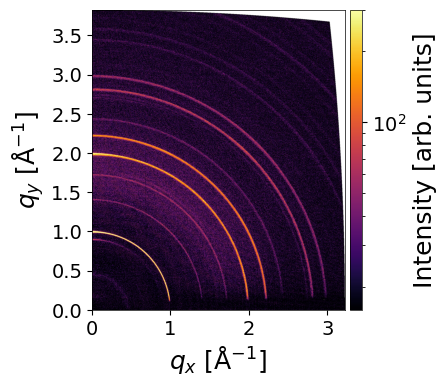

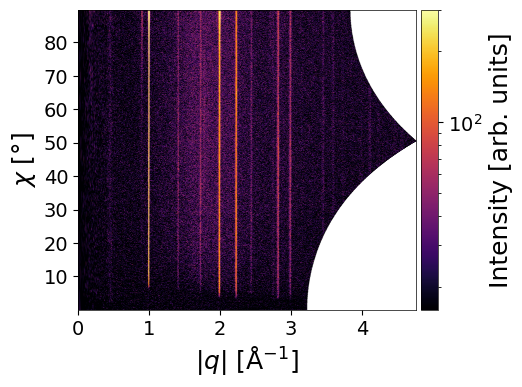

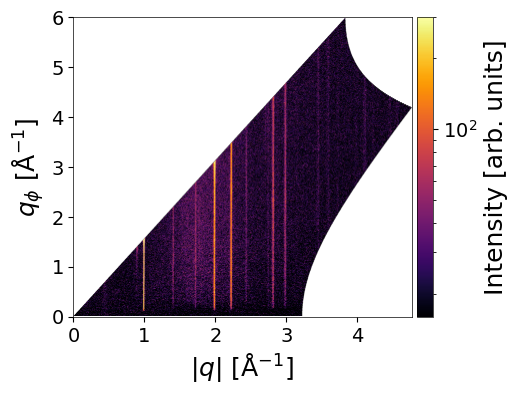

In [5]:
q_x, q_y, img =  analysis.det2q(plot_result=True, return_result=True, clims=(16,300))
q_abs, ang, img = analysis.det2pol( plot_result=True, return_result=True, clims=(16,300))
q_rad, q_azim, img = analysis.det2pseudopol(plot_result=True, return_result=True, clims=(16,300))

### One-dimensional conversion

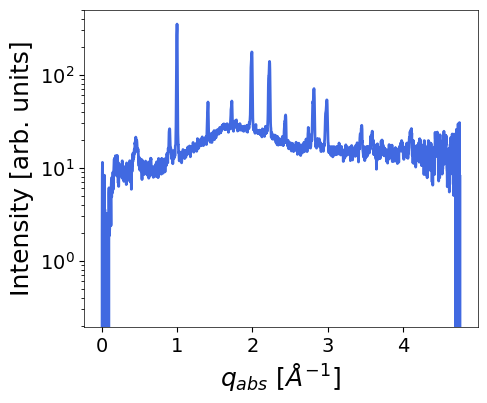

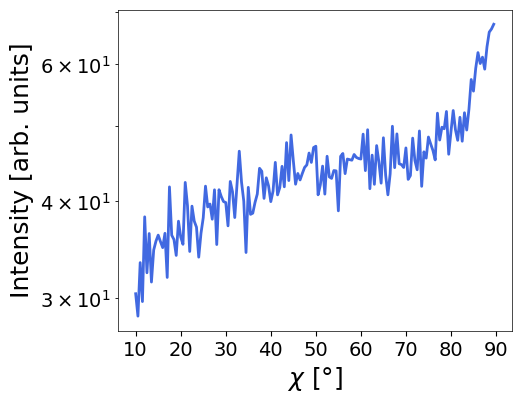

In [10]:
q_abs, img =  analysis.radial_profile(plot_result=True, return_result=True)
chi, img = analysis.azim_profile( plot_result=True, return_result=True,
                                  radial_range = (1.9, 2.1), # radial range in A-1
                                  angular_range = (10, 90)   # angular range in A-1
                                  )

## GISAXS

For many practical cases, the effect of the missing wedge at very small exit angles can be neglected, allowing the use of transmission-geometry functions for approximate analysis. However, for quantitative studies near the critical angle or for very thin films, missing-wedge corrections may be necessary.